In [1]:
!pip install ultralytics
!pip install cv2

You should consider upgrading via the 'D:\Facultate\AN4\licenta\img-to-3d\pipelineEnv\Scripts\python.exe -m pip install --upgrade pip' command.
ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2
You should consider upgrading via the 'D:\Facultate\AN4\licenta\img-to-3d\pipelineEnv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
from ultralytics import YOLO

# Load the model (make sure you use an object detection model; here we use "yolo11x.pt")
model = YOLO("yolo11x.pt")  # load an official model

# Predict on a local image ("room.jpg") with a lower confidence threshold (e.g., 0.3) to get more objects
results = model("room.jpg", conf=0.3)  # returns a list of result objects

# Access the results and print details
for result in results:
    print("Boxes:", result.boxes.xyxy)  # bounding box coordinates in [x1, y1, x2, y2] format
    print("Classes:", [result.names[int(cls)] for cls in result.boxes.cls])
    print("Confidences:", result.boxes.conf)

# Display the image with bounding boxes for each result.
# If there's only one image, you can call:
results[0].show()  # this will open a window with the image and boxes drawn


100%|███████████████████████████████████████████████████████████████████████████| 109M/109M [00:12<00:00, 9.34MB/s]



image 1/1 D:\Facultate\AN4\licenta\img-to-3d\room.jpg: 448x640 1 potted plant, 1 bed, 525.2ms
Speed: 1.8ms preprocess, 525.2ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Boxes: tensor([[185.5149, 226.8315, 430.0365, 350.3719],
        [441.6101, 121.1432, 536.7479, 317.0838]])
Classes: ['bed', 'potted plant']
Confidences: tensor([0.9293, 0.8532])


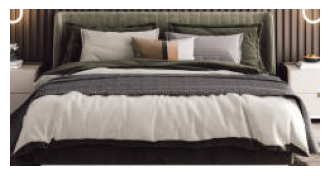

Saved detected_objects/object_0_0.jpg


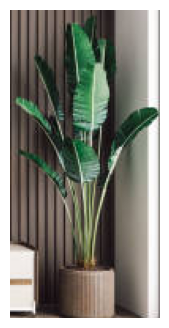

Saved detected_objects/object_0_1.jpg


In [4]:
import cv2
import os
import matplotlib.pyplot as plt

# Read the original image using OpenCV
img = cv2.imread("room.jpg")

# Create a directory to save cropped objects if it doesn't already exist
os.makedirs("detected_objects", exist_ok=True)

# Loop over each result (usually one result per input image)
for idx, result in enumerate(results):
    # Get the bounding box coordinates (convert from tensor to numpy array)
    boxes = result.boxes.xyxy.cpu().numpy()
    # Get the corresponding class names (using the model's names dictionary)
    classes = [result.names[int(cls)] for cls in result.boxes.cls.cpu().numpy()]
    # Get confidence scores
    confidences = result.boxes.conf.cpu().numpy()
    
    # Iterate over each detected object
    for i, (box, cls, conf) in enumerate(zip(boxes, classes, confidences)):
        # Convert box coordinates to integers
        x1, y1, x2, y2 = map(int, box)
        # Crop the object from the image
        crop_img = img[y1:y2, x1:x2]
        
        # Display the cropped object using matplotlib without text
        plt.figure(figsize=(4, 4))
        plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
        
        # Save the cropped object to the output folder
        crop_filename = f"detected_objects/object_{idx}_{i}.jpg"
        cv2.imwrite(crop_filename, crop_img)
        print(f"Saved {crop_filename}")


In [1]:
import os
import sys
import torch

# If needed, add the Direct3D repository to the PYTHONPATH:
# (Assuming the Direct3D folder is in the current working directory)
direct3d_repo_path = os.path.join(os.getcwd(), "Direct3D")
if direct3d_repo_path not in sys.path:
    sys.path.insert(0, direct3d_repo_path)
    print("Added Direct3D repo to sys.path")

# Import the Direct3D pipeline from the repository
from direct3d.pipeline import Direct3dPipeline

# Set device (GPU if available, otherwise CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load the pre-trained Direct3D pipeline from Hugging Face
pipeline = Direct3dPipeline.from_pretrained("DreamTechAI/Direct3D")
pipeline.to(device)

# Define input and output directories
cropped_dir = "detected_objects"  # folder with cropped object images (from YOLO)
output_dir = "3d_outputs"          # folder where .obj files will be saved
os.makedirs(output_dir, exist_ok=True)

# Process each cropped image through the Direct3D pipeline
for filename in os.listdir(cropped_dir):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(cropped_dir, filename)
        print(f"Processing {img_path}...")
        # Run inference on the cropped image
        # You can adjust parameters (remove_background, mc_threshold, guidance_scale, num_inference_steps) as needed.
        output = pipeline(
            img_path,
            remove_background=True,  # change to True if you need background removal
            mc_threshold=-1.0,
            guidance_scale=4.0,
            num_inference_steps=25,
        )
        # Assume the pipeline returns a dictionary with a key "meshes"
        mesh = output["meshes"][0]
        # Define the output filename (change extension to .obj)
        out_filename = os.path.splitext(filename)[0] + ".obj"
        out_path = os.path.join(output_dir, out_filename)
        # Export the 3D mesh as an OBJ file
        mesh.export(out_path)
        print(f"Saved 3D model as {out_path}")

Added Direct3D repo to sys.path


D:\Facultate\AN4\licenta\img-to-3d\pipelineEnv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0


D:\Facultate\AN4\licenta\img-to-3d\pipelineEnv\lib\site-packages\diffusers\models\embeddings.py:304: FutureWarning: `get_2d_sincos_pos_embed_from_grid` uses `torch` and supports `device`. `from_numpy` is no longer required.  Pass `output_type='pt' to use the new version now.
  deprecate("output_type=='np'", "0.33.0", deprecation_message, standard_warn=False)
D:\Facultate\AN4\licenta\img-to-3d\pipelineEnv\lib\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Processing detected_objects\object_0_0.jpg...


100%|########################################| 176M/176M [00:00<00:00, 179GB/s]
Triplane Sampling:: 100%|███████████████████████████████████████████████████████| 2701/2701 [02:41<00:00, 16.75it/s]


Saved 3D model as 3d_outputs\object_0_0.obj
Processing detected_objects\object_0_1.jpg...


Triplane Sampling:: 100%|███████████████████████████████████████████████████████| 2701/2701 [03:11<00:00, 14.11it/s]


Saved 3D model as 3d_outputs\object_0_1.obj
